In [2]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Isabella\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# MODELO XGBOOST: CLASIFICACIÓN MULTILABEL DE PATOLOGÍAS CEREBRALES

## Objetivo
Entrenar y evaluar un modelo XGBoost para clasificación multilabel de 4 patologías (hemorragia, ACV, fractura, masa) a partir de texto clínico (campo `Hallazgos`), utilizando **exactamente** la misma configuración experimental que los modelos baseline (SVM Linear, Random Forest, Logistic Regression, Naive Bayes).

## Diseño experimental
- **Representación**: TF-IDF (`max_features=200`, `ngram_range=(1,2)`, `min_df=5`, `max_df=0.8`)
- **Split**: 80/20 estratificado (`random_state=42`)
- **Estrategia multilabel**: One-vs-Rest (un clasificador binario por patología)
- **Métricas**: F1-macro, Recall-macro, Precision-macro, F1 por clase, Cohen's Kappa
- **Validación**: K-Fold estratificado (K=5)
- **Secciones**: (1) XGBoost base, (2) XGBoost con `scale_pos_weight` calculado desde train

## 1. Importaciones y configuración

In [3]:
# =============================================================================
# IMPORTACIONES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost
from xgboost import XGBClassifier

# Sklearn: preprocesamiento, evaluación y validación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Configuración visual y reproducibilidad
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

print("Importaciones completadas")

Importaciones completadas


## 2. Carga de datos y vectorización TF-IDF

Se utiliza la misma configuración de TF-IDF que en el notebook de Modelos Tradicionales para garantizar comparabilidad directa:
- `max_features=200`, `ngram_range=(1,2)`, `min_df=5`, `max_df=0.8`
- Stopwords personalizadas en español
- Vectorizador ajustado **exclusivamente** con datos de entrenamiento

In [4]:
# =============================================================================
# CARGA DE DATOS
# =============================================================================

df = pd.read_excel('../data/data_cleaned.xlsx')

print("=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
print(f"Total de registros: {len(df)}")
print(f"Columnas: {df.shape[1]}")

# Definir patologías (etiquetas multilabel)
patologias = ['hemorragia', 'acv', 'fractura', 'masa']

print(f"\nPatologías a clasificar: {patologias}")
print(f"\nDistribución de clases (positivos):")
for pat in patologias:
    n_pos = df[pat].sum()
    print(f"  {pat:12s}: {n_pos:3d} positivos ({n_pos/len(df)*100:.1f}%)")

FileNotFoundError: [Errno 2] No such file or directory: '../data/data_cleaned.xlsx'

In [ ]:
# =============================================================================
# SPLIT TRAIN/TEST ESTRATIFICADO + VECTORIZACIÓN TF-IDF
# =============================================================================

# Texto de entrada
X_text = df['Hallazgos'].astype(str)

# Etiquetas multilabel (matriz binaria)
y = df[patologias].values

# Split estratificado 80/20 (estratificar por primera patología, consistente con notebooks previos)
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=df[patologias[0]].values  # Estratificación por hemorragia
)

print("=" * 60)
print("DIVISIÓN TRAIN/TEST")
print("=" * 60)
print(f"Train: {len(X_text_train)} muestras")
print(f"Test:  {len(X_text_test)} muestras")

# Stopwords idénticas a notebooks anteriores
stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

# Vectorización TF-IDF: fit SOLO con datos de entrenamiento
vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X_train = vectorizer.fit_transform(X_text_train)   # fit + transform en TRAIN
X_test  = vectorizer.transform(X_text_test)          # solo transform en TEST

print(f"\nVectorización TF-IDF (fit solo en train):")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Features (términos TF-IDF): {X_train.shape[1]}")

# Distribución de clases en TRAIN (para referencia)
print(f"\nDistribución de clases en TRAIN:")
for idx, pat in enumerate(patologias):
    n_pos = y_train[:, idx].sum()
    n_neg = len(y_train) - n_pos
    print(f"  {pat:12s}: {n_pos:3.0f} pos / {n_neg:3.0f} neg (ratio 1:{n_neg/n_pos:.2f})")

DIVISIÓN TRAIN/TEST
Train: 716 muestras
Test:  179 muestras

Vectorización TF-IDF (fit solo en train):
  X_train: (716, 200)
  X_test:  (179, 200)
  Features (términos TF-IDF): 200

Distribución de clases en TRAIN:
  hemorragia  : 575 pos / 141 neg (ratio 1:0.25)
  acv         : 320 pos / 396 neg (ratio 1:1.24)
  fractura    : 299 pos / 417 neg (ratio 1:1.39)
  masa        : 167 pos / 549 neg (ratio 1:3.29)


## 3. XGBoost Base (sin ajuste de desbalance)

Entrenamiento de XGBoost con parámetros por defecto, usando `OneVsRestClassifier` para el problema multilabel. Esta versión **no aplica oversampling ni ajuste de `scale_pos_weight`**, sirviendo como punto de referencia para medir el efecto posterior del balanceo.

### Hiperparámetros base:
- `n_estimators=100` (comparable con Random Forest)
- `max_depth=6` (default de XGBoost)
- `learning_rate=0.3` (default)
- `eval_metric='logloss'` (clasificación binaria)
- `random_state=42` (reproducibilidad)

In [ ]:
# =============================================================================
# ENTRENAMIENTO XGBOOST BASE (SIN AJUSTE DE DESBALANCE)
# =============================================================================

print("=" * 70)
print("XGBOOST BASE - CLASIFICACIÓN MULTILABEL (ONE-VS-REST)")
print("=" * 70)

# Definir clasificador base XGBoost
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Entrenar un clasificador por patología (One-vs-Rest manual para mayor control)
modelos_base = {}
predicciones_base = {}
resultados_base = []

for idx, patologia in enumerate(patologias):
    print(f"\n{'─'*50}")
    print(f"Entrenando: {patologia.upper()}")
    print(f"{'─'*50}")
    
    # Extraer etiquetas binarias para esta patología
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    # Clonar y entrenar
    modelo = clone(xgb_base)
    modelo.fit(X_train, y_train_pat)
    
    # Predecir en test
    y_pred = modelo.predict(X_test)
    
    # Calcular métricas
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    print(f"  F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f}")
    
    # Almacenar modelo y predicciones
    modelos_base[patologia] = modelo
    predicciones_base[patologia] = {
        'y_pred': y_pred,
        'y_test': y_test_pat
    }
    
    resultados_base.append({
        'Patología': patologia,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa
    })

# Calcular métricas MACRO (promedio de las 4 patologías)
f1_macro_base = np.mean([r['F1'] for r in resultados_base])
recall_macro_base = np.mean([r['Recall'] for r in resultados_base])
precision_macro_base = np.mean([r['Precision'] for r in resultados_base])
kappa_macro_base = np.mean([r['Kappa'] for r in resultados_base])

print(f"\n{'='*70}")
print(f"MÉTRICAS MACRO (XGBoost Base)")
print(f"{'='*70}")
print(f"  F1-macro:        {f1_macro_base:.4f}")
print(f"  Recall-macro:    {recall_macro_base:.4f}")
print(f"  Precision-macro: {precision_macro_base:.4f}")
print(f"  Kappa-macro:     {kappa_macro_base:.4f}")
print(f"{'='*70}")

XGBOOST BASE - CLASIFICACIÓN MULTILABEL (ONE-VS-REST)

──────────────────────────────────────────────────
Entrenando: HEMORRAGIA
──────────────────────────────────────────────────
  F1: 0.949 | Recall: 0.965 | Precision: 0.933 | Kappa: 0.718

──────────────────────────────────────────────────
Entrenando: ACV
──────────────────────────────────────────────────
  F1: 0.980 | Recall: 0.961 | Precision: 1.000 | Kappa: 0.966

──────────────────────────────────────────────────
Entrenando: FRACTURA
──────────────────────────────────────────────────
  F1: 0.944 | Recall: 0.938 | Precision: 0.950 | Kappa: 0.898

──────────────────────────────────────────────────
Entrenando: MASA
──────────────────────────────────────────────────
  F1: 0.854 | Recall: 0.884 | Precision: 0.826 | Kappa: 0.806

MÉTRICAS MACRO (XGBoost Base)
  F1-macro:        0.9317
  Recall-macro:    0.9371
  Precision-macro: 0.9272
  Kappa-macro:     0.8470


## 4. Evaluación detallada del modelo base

Reportes de clasificación por patología, matrices de confusión y tabla resumen comparativa.

REPORTES DE CLASIFICACIÓN POR PATOLOGÍA (XGBoost Base)

──────────────────────────────────────────────────
HEMORRAGIA
──────────────────────────────────────────────────
                precision    recall  f1-score   support

Sin hemorragia      0.833     0.714     0.769        35
    Hemorragia      0.933     0.965     0.949       144

      accuracy                          0.916       179
     macro avg      0.883     0.840     0.859       179
  weighted avg      0.913     0.916     0.914       179


──────────────────────────────────────────────────
ACV
──────────────────────────────────────────────────
              precision    recall  f1-score   support

     Sin ACV      0.971     1.000     0.986       102
         ACV      1.000     0.961     0.980        77

    accuracy                          0.983       179
   macro avg      0.986     0.981     0.983       179
weighted avg      0.984     0.983     0.983       179


──────────────────────────────────────────────────
FRACTU

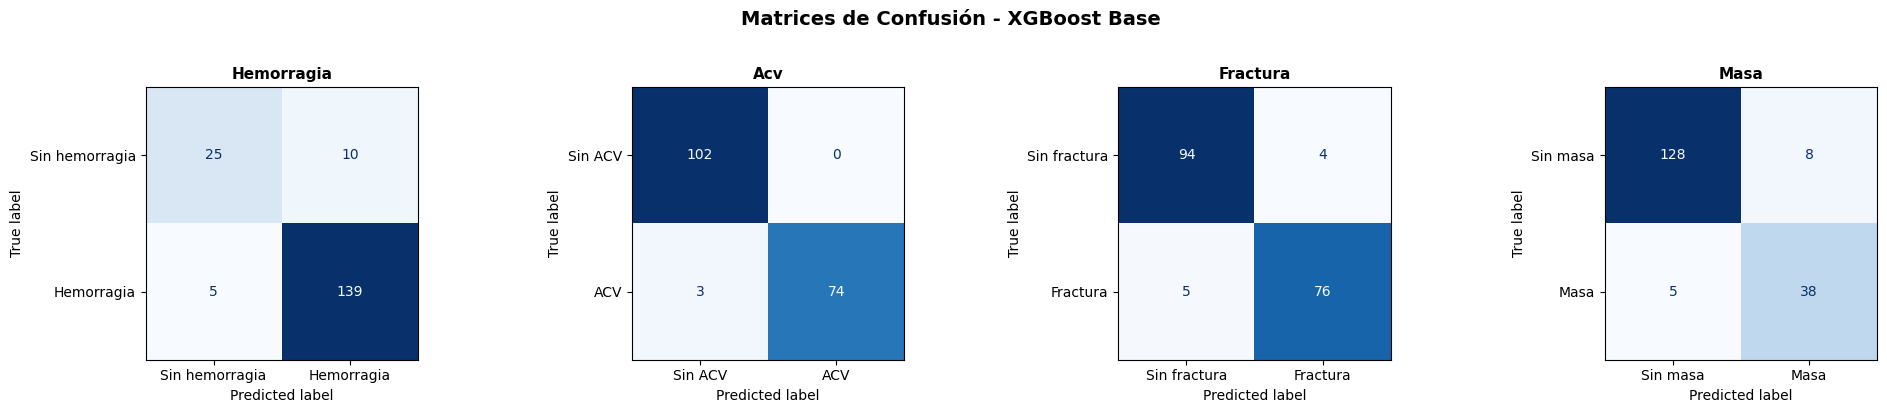

In [ ]:
# =============================================================================
# REPORTES DE CLASIFICACIÓN Y MATRICES DE CONFUSIÓN (XGBOOST BASE)
# =============================================================================

print("=" * 70)
print("REPORTES DE CLASIFICACIÓN POR PATOLOGÍA (XGBoost Base)")
print("=" * 70)

# Etiquetas descriptivas por patología
etiquetas_dict = {
    'hemorragia': ['Sin hemorragia', 'Hemorragia'],
    'acv':        ['Sin ACV', 'ACV'],
    'fractura':   ['Sin fractura', 'Fractura'],
    'masa':       ['Sin masa', 'Masa']
}

for patologia in patologias:
    y_test_pat = predicciones_base[patologia]['y_test']
    y_pred_pat = predicciones_base[patologia]['y_pred']
    etiquetas  = etiquetas_dict[patologia]
    
    print(f"\n{'─'*50}")
    print(f"{patologia.upper()}")
    print(f"{'─'*50}")
    print(classification_report(y_test_pat, y_pred_pat, 
                                 target_names=etiquetas, digits=3))
    kappa_pat = cohen_kappa_score(y_test_pat, y_pred_pat)
    print(f"  Cohen's Kappa: {kappa_pat:.4f}")

# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, patologia in enumerate(patologias):
    y_test_pat = predicciones_base[patologia]['y_test']
    y_pred_pat = predicciones_base[patologia]['y_pred']
    etiquetas  = etiquetas_dict[patologia]
    
    cm = confusion_matrix(y_test_pat, y_pred_pat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False, values_format='d')
    axes[idx].set_title(f"{patologia.capitalize()}", fontweight='bold', fontsize=11)

plt.suptitle("Matrices de Confusión - XGBoost Base", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# TABLA RESUMEN DE MÉTRICAS (XGBOOST BASE)
# =============================================================================

print("=" * 70)
print("TABLA RESUMEN: XGBOOST BASE")
print("=" * 70)

df_resultados_base = pd.DataFrame(resultados_base)
df_resultados_base = df_resultados_base.set_index('Patología')

print("\nMétricas por patología:")
print(df_resultados_base.round(4).to_string())

# Fila de promedios macro
print(f"\n{'─'*50}")
print(f"{'MACRO':<12s}  Precision: {precision_macro_base:.4f}  "
      f"Recall: {recall_macro_base:.4f}  "
      f"F1: {f1_macro_base:.4f}  "
      f"Kappa: {kappa_macro_base:.4f}")
print(f"{'─'*50}")

# Comparación rápida con baselines previos (valores del notebook 2)
print(f"\n{'='*70}")
print("REFERENCIA: MEJORES BASELINES (Notebook 2 - Modelos Tradicionales)")
print("=" * 70)
print(f"  SVM Linear:          F1-macro = 0.909 | Recall-macro = 0.931 | Precision-macro = 0.893")
print(f"  Random Forest:       F1-macro = 0.902 | Recall-macro = 0.872 | Precision-macro = 0.946")
print(f"  Logistic Regression: F1-macro = 0.890 | Recall-macro = 0.926 | Precision-macro = 0.862")
print(f"\n  XGBoost Base:        F1-macro = {f1_macro_base:.3f} | Recall-macro = {recall_macro_base:.3f} | Precision-macro = {precision_macro_base:.3f}")
print("=" * 70)

TABLA RESUMEN: XGBOOST BASE

Métricas por patología:
            Precision  Recall      F1   Kappa
Patología                                    
hemorragia     0.9329  0.9653  0.9488  0.7184
acv            1.0000  0.9610  0.9801  0.9656
fractura       0.9500  0.9383  0.9441  0.8984
masa           0.8261  0.8837  0.8539  0.8057

──────────────────────────────────────────────────
MACRO         Precision: 0.9272  Recall: 0.9371  F1: 0.9317  Kappa: 0.8470
──────────────────────────────────────────────────

REFERENCIA: MEJORES BASELINES (Notebook 2 - Modelos Tradicionales)
  SVM Linear:          F1-macro = 0.909 | Recall-macro = 0.931 | Precision-macro = 0.893
  Random Forest:       F1-macro = 0.902 | Recall-macro = 0.872 | Precision-macro = 0.946
  Logistic Regression: F1-macro = 0.890 | Recall-macro = 0.926 | Precision-macro = 0.862

  XGBoost Base:        F1-macro = 0.932 | Recall-macro = 0.937 | Precision-macro = 0.927


---

## 5. Validación Cruzada Estratificada con Pipeline (K=5)

### Diseño metodológico

Para garantizar la ausencia de data leakage en la estimación de rendimiento fuera de muestra, se emplea un `sklearn.pipeline.Pipeline` que encapsula **en un único objeto estimable** el vectorizador TF-IDF y el clasificador XGBoost. Al pasar este Pipeline a `cross_val_score`, scikit-learn ejecuta en cada fold las operaciones siguientes, en estricto orden:

1. `pipeline.fit(X_train_fold)` — Ajusta el vocabulario TF-IDF y entrena el clasificador **exclusivamente** con los datos de entrenamiento del fold.
2. `pipeline.predict(X_val_fold)` — Transforma el texto *crudo* del fold de validación usando el vocabulario aprendido en el paso anterior, y genera predicciones.



VALIDACIÓN CRUZADA CON PIPELINE (K=5) — IMPLEMENTACIÓN OFICIAL

Flujo por fold:
  1. pipeline.fit(X_train_fold)  → TF-IDF ajustado solo en train del fold
  2. pipeline.predict(X_val_fold) → texto crudo transformado con vocab. del fold
  Entrada: X_text (texto crudo) — sin pre-vectorización externa

  hemorragia    F1: 0.952 ± 0.007  |  Recall: 0.957 ± 0.012  |  Precision: 0.948 ± 0.012
  acv           F1: 0.966 ± 0.022  |  Recall: 0.947 ± 0.035  |  Precision: 0.987 ± 0.009
  fractura      F1: 0.958 ± 0.009  |  Recall: 0.968 ± 0.024  |  Precision: 0.949 ± 0.010
  masa          F1: 0.812 ± 0.019  |  Recall: 0.814 ± 0.041  |  Precision: 0.816 ± 0.068

RESULTADOS GLOBALES (Pipeline CV — valores oficiales)
  F1-macro     :  0.922 ± 0.014
  Recall-macro :  0.922
  Precision-macro: 0.925

  Referencia — SVM Linear CV (baseline):  0.898 ± 0.019
  XGBoost Pipeline CV:                    0.922 ± 0.014  (Δ = +0.024 vs SVM Linear)


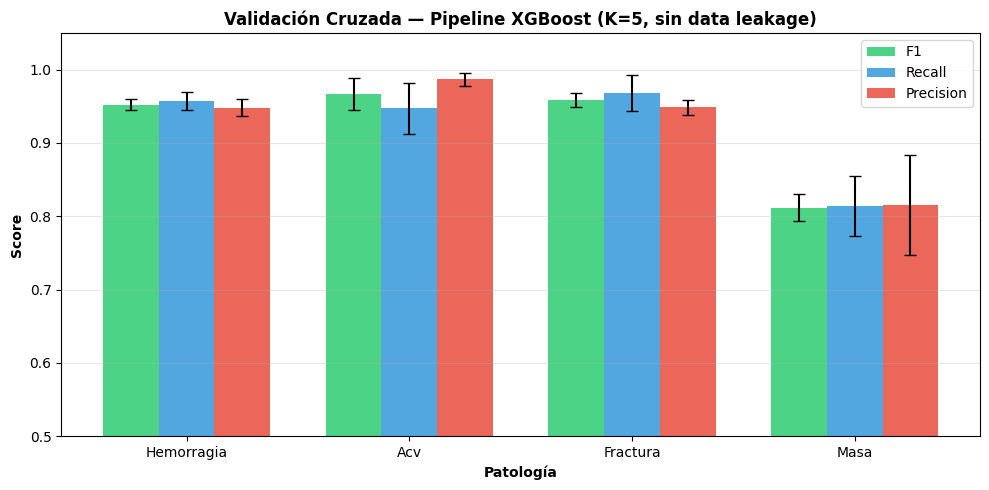

In [ ]:
# =============================================================================
# VALIDACIÓN CRUZADA CON PIPELINE — SIN DATA LEAKAGE (IMPLEMENTACIÓN OFICIAL)
# =============================================================================

from sklearn.pipeline import Pipeline

print("=" * 70)
print("VALIDACIÓN CRUZADA CON PIPELINE (K=5) — IMPLEMENTACIÓN OFICIAL")
print("=" * 70)
print()
print("Flujo por fold:")
print("  1. pipeline.fit(X_train_fold)  → TF-IDF ajustado solo en train del fold")
print("  2. pipeline.predict(X_val_fold) → texto crudo transformado con vocab. del fold")
print("  Entrada: X_text (texto crudo) — sin pre-vectorización externa")
print()

# ------------------------------------------------------------------
# Definición del Pipeline: TF-IDF + XGBoost en un único estimador
# ------------------------------------------------------------------
pipeline_cv = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=200,
        min_df=5,
        max_df=0.8,
        ngram_range=(1, 2),
        stop_words=stopwords_es
    )),
    ('clf', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

skf_pipeline = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------------
# Evaluación por patología (One-vs-Rest)
# ------------------------------------------------------------------
resultados_cv_pipeline = []

for patologia in patologias:
    y_cv_pat = df[patologia].values  # Etiqueta binaria (1D)

    scores_f1   = cross_val_score(clone(pipeline_cv), X_text, y_cv_pat,
                                  cv=skf_pipeline, scoring='f1',        n_jobs=-1)
    scores_rec  = cross_val_score(clone(pipeline_cv), X_text, y_cv_pat,
                                  cv=skf_pipeline, scoring='recall',    n_jobs=-1)
    scores_prec = cross_val_score(clone(pipeline_cv), X_text, y_cv_pat,
                                  cv=skf_pipeline, scoring='precision', n_jobs=-1)

    resultados_cv_pipeline.append({
        'Patología':      patologia,
        'F1_mean':        scores_f1.mean(),
        'F1_std':         scores_f1.std(),
        'Recall_mean':    scores_rec.mean(),
        'Recall_std':     scores_rec.std(),
        'Precision_mean': scores_prec.mean(),
        'Precision_std':  scores_prec.std(),
    })

    print(f"  {patologia:12s}  F1: {scores_f1.mean():.3f} ± {scores_f1.std():.3f}  |  "
          f"Recall: {scores_rec.mean():.3f} ± {scores_rec.std():.3f}  |  "
          f"Precision: {scores_prec.mean():.3f} ± {scores_prec.std():.3f}")

# ------------------------------------------------------------------
# Métricas macro (promedio no ponderado sobre las 4 patologías)
# ------------------------------------------------------------------
f1_macro_cv_pipe      = np.mean([r['F1_mean']        for r in resultados_cv_pipeline])
f1_macro_cv_pipe_std  = np.mean([r['F1_std']         for r in resultados_cv_pipeline])
rec_macro_cv_pipe     = np.mean([r['Recall_mean']    for r in resultados_cv_pipeline])
prec_macro_cv_pipe    = np.mean([r['Precision_mean'] for r in resultados_cv_pipeline])

print()
print("=" * 70)
print("RESULTADOS GLOBALES (Pipeline CV — valores oficiales)")
print("=" * 70)
print(f"  F1-macro     :  {f1_macro_cv_pipe:.3f} ± {f1_macro_cv_pipe_std:.3f}")
print(f"  Recall-macro :  {rec_macro_cv_pipe:.3f}")
print(f"  Precision-macro: {prec_macro_cv_pipe:.3f}")
print()
print(f"  Referencia — SVM Linear CV (baseline):  0.898 ± 0.019")
delta_svm = f1_macro_cv_pipe - 0.898
signo_svm = f"+{delta_svm:.3f}" if delta_svm >= 0 else f"{delta_svm:.3f}"
print(f"  XGBoost Pipeline CV:                    {f1_macro_cv_pipe:.3f} ± {f1_macro_cv_pipe_std:.3f}  (Δ = {signo_svm} vs SVM Linear)")
print("=" * 70)

# ------------------------------------------------------------------
# Visualización: barras con intervalos de confianza
# ------------------------------------------------------------------
df_cv_pipe = pd.DataFrame(resultados_cv_pipeline).set_index('Patología')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(patologias))
w = 0.25

ax.bar(x - w, df_cv_pipe['F1_mean'],        w, yerr=df_cv_pipe['F1_std'],        capsize=4,
       label='F1',        color='#2ecc71', alpha=0.85)
ax.bar(x,     df_cv_pipe['Recall_mean'],    w, yerr=df_cv_pipe['Recall_std'],    capsize=4,
       label='Recall',    color='#3498db', alpha=0.85)
ax.bar(x + w, df_cv_pipe['Precision_mean'], w, yerr=df_cv_pipe['Precision_std'], capsize=4,
       label='Precision', color='#e74c3c', alpha=0.85)

ax.set_xlabel('Patología', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Validación Cruzada — Pipeline XGBoost (K=5, sin data leakage)',
             fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in patologias])
ax.set_ylim([0.5, 1.05])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---

## 6. XGBoost con `scale_pos_weight` (ajuste de desbalance)

### Estrategia
Se calcula `scale_pos_weight = n_negativos / n_positivos` **exclusivamente con los datos de entrenamiento** para cada patología. Este parámetro le indica a XGBoost que penalice más los errores en la clase positiva (minoritaria), funcionando de manera análoga a `class_weight='balanced'` en SVM y Random Forest.

### Ventaja frente a oversampling
- No duplica ni genera muestras sintéticas
- No incrementa el tiempo de entrenamiento
- Regulación interna del gradiente (más elegante que ROS/SMOTE para gradient boosting)

In [ ]:
# =============================================================================
# CÁLCULO DE scale_pos_weight POR PATOLOGÍA (SOLO DESDE TRAIN)
# =============================================================================

print("=" * 70)
print("CÁLCULO DE scale_pos_weight (EXCLUSIVAMENTE DESDE TRAIN)")
print("=" * 70)

scale_weights = {}

for idx, patologia in enumerate(patologias):
    y_train_pat = y_train[:, idx]
    
    n_positivos = y_train_pat.sum()
    n_negativos = len(y_train_pat) - n_positivos
    spw = n_negativos / n_positivos
    
    scale_weights[patologia] = spw
    
    print(f"\n  {patologia.upper()}")
    print(f"    Train positivos: {n_positivos:.0f}")
    print(f"    Train negativos: {n_negativos:.0f}")
    print(f"    scale_pos_weight = {n_negativos:.0f} / {n_positivos:.0f} = {spw:.4f}")

print(f"\n{'='*70}")
print("Nota: Estos valores se usarán individualmente en cada clasificador binario")
print("      para compensar el desbalance de cada patología.")
print(f"{'='*70}")

CÁLCULO DE scale_pos_weight (EXCLUSIVAMENTE DESDE TRAIN)

  HEMORRAGIA
    Train positivos: 575
    Train negativos: 141
    scale_pos_weight = 141 / 575 = 0.2452

  ACV
    Train positivos: 320
    Train negativos: 396
    scale_pos_weight = 396 / 320 = 1.2375

  FRACTURA
    Train positivos: 299
    Train negativos: 417
    scale_pos_weight = 417 / 299 = 1.3946

  MASA
    Train positivos: 167
    Train negativos: 549
    scale_pos_weight = 549 / 167 = 3.2874

Nota: Estos valores se usarán individualmente en cada clasificador binario
      para compensar el desbalance de cada patología.


In [ ]:
# =============================================================================
# ENTRENAMIENTO XGBOOST CON scale_pos_weight
# =============================================================================

print("=" * 70)
print("XGBOOST CON scale_pos_weight - CLASIFICACIÓN MULTILABEL")
print("=" * 70)

modelos_balanced = {}
predicciones_balanced = {}
resultados_balanced = []

for idx, patologia in enumerate(patologias):
    print(f"\n{'─'*50}")
    print(f"Entrenando: {patologia.upper()} (scale_pos_weight = {scale_weights[patologia]:.4f})")
    print(f"{'─'*50}")
    
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    # Crear clasificador con scale_pos_weight específico para esta patología
    modelo = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        scale_pos_weight=scale_weights[patologia],
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
    
    modelo.fit(X_train, y_train_pat)
    y_pred = modelo.predict(X_test)
    
    # Calcular métricas
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    print(f"  F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f}")
    
    modelos_balanced[patologia] = modelo
    predicciones_balanced[patologia] = {
        'y_pred': y_pred,
        'y_test': y_test_pat
    }
    
    resultados_balanced.append({
        'Patología': patologia,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa,
        'scale_pos_weight': scale_weights[patologia]
    })

# Métricas MACRO
f1_macro_balanced = np.mean([r['F1'] for r in resultados_balanced])
recall_macro_balanced = np.mean([r['Recall'] for r in resultados_balanced])
precision_macro_balanced = np.mean([r['Precision'] for r in resultados_balanced])
kappa_macro_balanced = np.mean([r['Kappa'] for r in resultados_balanced])

print(f"\n{'='*70}")
print(f"MÉTRICAS MACRO (XGBoost con scale_pos_weight)")
print(f"{'='*70}")
print(f"  F1-macro:        {f1_macro_balanced:.4f}")
print(f"  Recall-macro:    {recall_macro_balanced:.4f}")
print(f"  Precision-macro: {precision_macro_balanced:.4f}")
print(f"  Kappa-macro:     {kappa_macro_balanced:.4f}")
print(f"{'='*70}")

XGBOOST CON scale_pos_weight - CLASIFICACIÓN MULTILABEL

──────────────────────────────────────────────────
Entrenando: HEMORRAGIA (scale_pos_weight = 0.2452)
──────────────────────────────────────────────────
  F1: 0.949 | Recall: 0.965 | Precision: 0.933 | Kappa: 0.718

──────────────────────────────────────────────────
Entrenando: ACV (scale_pos_weight = 1.2375)
──────────────────────────────────────────────────
  F1: 0.980 | Recall: 0.961 | Precision: 1.000 | Kappa: 0.966

──────────────────────────────────────────────────
Entrenando: FRACTURA (scale_pos_weight = 1.3946)
──────────────────────────────────────────────────
  F1: 0.944 | Recall: 0.938 | Precision: 0.950 | Kappa: 0.898

──────────────────────────────────────────────────
Entrenando: MASA (scale_pos_weight = 3.2874)
──────────────────────────────────────────────────
  F1: 0.851 | Recall: 0.930 | Precision: 0.784 | Kappa: 0.799

MÉTRICAS MACRO (XGBoost con scale_pos_weight)
  F1-macro:        0.9310
  Recall-macro:    0.9

REPORTES DE CLASIFICACIÓN (XGBoost con scale_pos_weight)

──────────────────────────────────────────────────
HEMORRAGIA (scale_pos_weight = 0.25)
──────────────────────────────────────────────────
                precision    recall  f1-score   support

Sin hemorragia      0.833     0.714     0.769        35
    Hemorragia      0.933     0.965     0.949       144

      accuracy                          0.916       179
     macro avg      0.883     0.840     0.859       179
  weighted avg      0.913     0.916     0.914       179


──────────────────────────────────────────────────
ACV (scale_pos_weight = 1.24)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

     Sin ACV      0.971     1.000     0.986       102
         ACV      1.000     0.961     0.980        77

    accuracy                          0.983       179
   macro avg      0.986     0.981     0.983       179
weighted avg      0.984     0.983     0.983       179


───

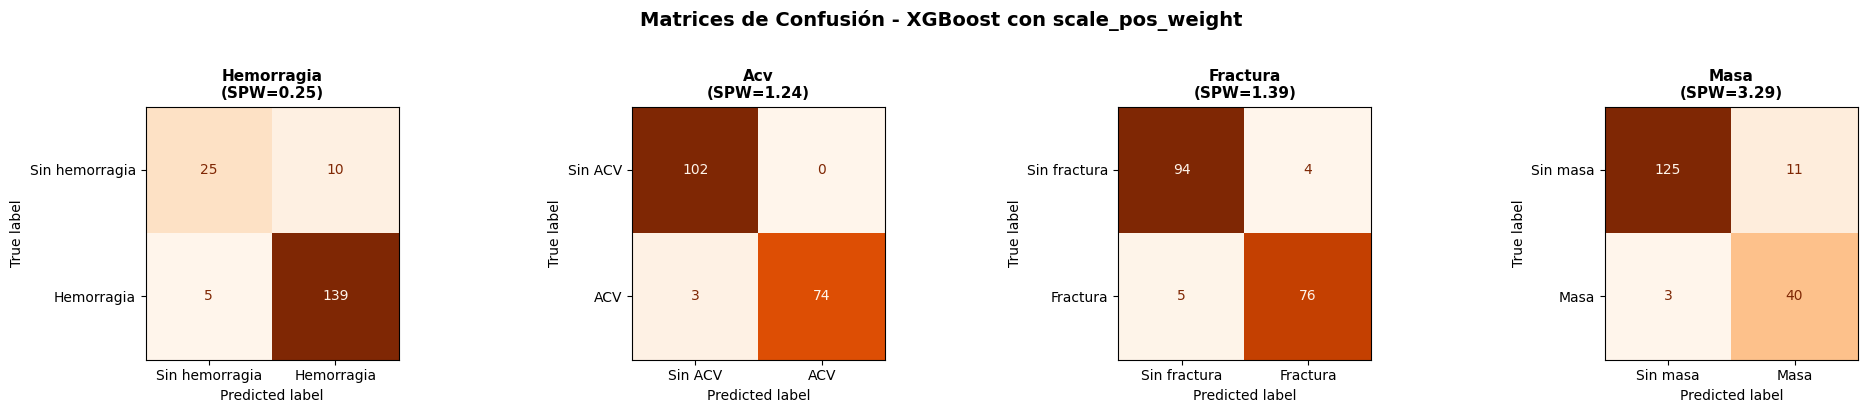

In [ ]:
# =============================================================================
# REPORTES Y MATRICES DE CONFUSIÓN (XGBOOST CON scale_pos_weight)
# =============================================================================

print("=" * 70)
print("REPORTES DE CLASIFICACIÓN (XGBoost con scale_pos_weight)")
print("=" * 70)

for patologia in patologias:
    y_test_pat = predicciones_balanced[patologia]['y_test']
    y_pred_pat = predicciones_balanced[patologia]['y_pred']
    etiquetas  = etiquetas_dict[patologia]
    
    print(f"\n{'─'*50}")
    print(f"{patologia.upper()} (scale_pos_weight = {scale_weights[patologia]:.2f})")
    print(f"{'─'*50}")
    print(classification_report(y_test_pat, y_pred_pat, 
                                 target_names=etiquetas, digits=3))
    kappa_pat_bal = cohen_kappa_score(y_test_pat, y_pred_pat)
    print(f"  Cohen's Kappa: {kappa_pat_bal:.4f}")

# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, patologia in enumerate(patologias):
    y_test_pat = predicciones_balanced[patologia]['y_test']
    y_pred_pat = predicciones_balanced[patologia]['y_pred']
    etiquetas  = etiquetas_dict[patologia]
    
    cm = confusion_matrix(y_test_pat, y_pred_pat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=axes[idx], cmap="Oranges", colorbar=False, values_format='d')
    axes[idx].set_title(f"{patologia.capitalize()}\n(SPW={scale_weights[patologia]:.2f})", 
                         fontweight='bold', fontsize=11)

plt.suptitle("Matrices de Confusión - XGBoost con scale_pos_weight", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Comparación: XGBoost Base vs XGBoost Balanced vs Baselines

Tabla comparativa unificada de ambas variantes de XGBoost junto con los modelos baseline del notebook de Modelos Tradicionales.

In [ ]:
# =============================================================================
# COMPARACIÓN BASE vs BALANCED (F1 POR PATOLOGÍA)
# =============================================================================

print("=" * 80)
print("COMPARACIÓN DETALLADA: XGBoost Base vs XGBoost Balanced")
print("=" * 80)

df_base = pd.DataFrame(resultados_base).set_index('Patología')
df_balanced = pd.DataFrame(resultados_balanced).set_index('Patología')

# Tabla comparativa por patología
print(f"\n{'Patología':<12s} | {'F1 Base':>8s} {'F1 Balanced':>12s} {'Δ F1':>8s} | "
      f"{'Recall Base':>12s} {'Recall Bal.':>12s} {'Δ Recall':>10s} | "
      f"{'Kappa Base':>11s} {'Kappa Bal.':>11s}")
print("─" * 120)

for pat in patologias:
    f1_b = df_base.loc[pat, 'F1']
    f1_w = df_balanced.loc[pat, 'F1']
    r_b  = df_base.loc[pat, 'Recall']
    r_w  = df_balanced.loc[pat, 'Recall']
    k_b  = df_base.loc[pat, 'Kappa']
    k_w  = df_balanced.loc[pat, 'Kappa']
    
    print(f"{pat:<12s} | {f1_b:>8.3f} {f1_w:>12.3f} {f1_w-f1_b:>+8.3f} | "
          f"{r_b:>12.3f} {r_w:>12.3f} {r_w-r_b:>+10.3f} | "
          f"{k_b:>11.3f} {k_w:>11.3f}")

print("─" * 120)
print(f"{'MACRO':<12s} | {f1_macro_base:>8.3f} {f1_macro_balanced:>12.3f} {f1_macro_balanced-f1_macro_base:>+8.3f} | "
      f"{recall_macro_base:>12.3f} {recall_macro_balanced:>12.3f} {recall_macro_balanced-recall_macro_base:>+10.3f} | "
      f"{kappa_macro_base:>11.3f} {kappa_macro_balanced:>11.3f}")

# Evaluación del impacto
print(f"\n{'='*80}")
print("ANÁLISIS DEL IMPACTO DE scale_pos_weight:")
print("=" * 80)

for pat in patologias:
    delta_f1 = df_balanced.loc[pat, 'F1'] - df_base.loc[pat, 'F1']
    delta_recall = df_balanced.loc[pat, 'Recall'] - df_base.loc[pat, 'Recall']
    
    if delta_f1 > 0.03:
        impacto = "MEJORA SIGNIFICATIVA"
    elif delta_f1 > 0:
        impacto = "MEJORA LEVE"
    elif delta_f1 > -0.03:
        impacto = "SIN CAMBIO RELEVANTE"
    else:
        impacto = "DETERIORO"
    
    print(f"  {pat:12s}: ΔF1 = {delta_f1:+.3f}, ΔRecall = {delta_recall:+.3f} → {impacto}")

COMPARACIÓN DETALLADA: XGBoost Base vs XGBoost Balanced

Patología    |  F1 Base  F1 Balanced     Δ F1 |  Recall Base  Recall Bal.   Δ Recall |  Kappa Base  Kappa Bal.
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
hemorragia   |    0.949        0.949   +0.000 |        0.965        0.965     +0.000 |       0.718       0.718
acv          |    0.980        0.980   +0.000 |        0.961        0.961     +0.000 |       0.966       0.966
fractura     |    0.944        0.944   +0.000 |        0.938        0.938     +0.000 |       0.898       0.898
masa         |    0.854        0.851   -0.003 |        0.884        0.930     +0.047 |       0.806       0.799
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
MACRO        |    0.932        0.931   -0.001 |        0.937        0.949     +0.012 |       0.847       0.845

ANÁLISIS DEL IMPACTO DE scale_pos_

In [ ]:
# =============================================================================
# TABLA RESUMEN GLOBAL: TODOS LOS MODELOS
# =============================================================================

print("=" * 80)
print("TABLA RESUMEN GLOBAL: COMPARACIÓN CON BASELINES PREVIOS")
print("=" * 80)

# Construir tabla con todos los modelos (baselines del notebook 2 + XGBoost)
resumen_global = [
    # Baselines del notebook 2 (valores reportados)
    {'Modelo': 'SVM Linear',          'F1_macro': 0.909, 'Recall_macro': 0.931, 'Precision_macro': 0.893, 'Kappa_macro': 0.862,
     'F1_hemorragia': 0.928, 'F1_acv': 0.921, 'F1_fractura': 0.961, 'F1_masa': 0.826},
    {'Modelo': 'Random Forest',       'F1_macro': 0.902, 'Recall_macro': 0.872, 'Precision_macro': 0.946, 'Kappa_macro': 0.844,
     'F1_hemorragia': 0.949, 'F1_acv': 0.974, 'F1_fractura': 0.953, 'F1_masa': 0.732},
    {'Modelo': 'Logistic Regression', 'F1_macro': 0.890, 'Recall_macro': 0.926, 'Precision_macro': 0.862, 'Kappa_macro': 0.831,
     'F1_hemorragia': 0.917, 'F1_acv': 0.909, 'F1_fractura': 0.909, 'F1_masa': 0.825},
    {'Modelo': 'Naive Bayes',         'F1_macro': 0.768, 'Recall_macro': 0.662, 'Precision_macro': 0.926, 'Kappa_macro': 0.691,
     'F1_hemorragia': 0.876, 'F1_acv': 0.690, 'F1_fractura': 0.935, 'F1_masa': 0.571},
    # XGBoost (calculados en este notebook)
    {'Modelo': 'XGBoost Base',
     'F1_macro': f1_macro_base,
     'Recall_macro': recall_macro_base,
     'Precision_macro': precision_macro_base,
     'Kappa_macro': kappa_macro_base,
     'F1_hemorragia': df_base.loc['hemorragia', 'F1'],
     'F1_acv': df_base.loc['acv', 'F1'],
     'F1_fractura': df_base.loc['fractura', 'F1'],
     'F1_masa': df_base.loc['masa', 'F1']},
    {'Modelo': 'XGBoost Balanced',
     'F1_macro': f1_macro_balanced,
     'Recall_macro': recall_macro_balanced,
     'Precision_macro': precision_macro_balanced,
     'Kappa_macro': kappa_macro_balanced,
     'F1_hemorragia': df_balanced.loc['hemorragia', 'F1'],
     'F1_acv': df_balanced.loc['acv', 'F1'],
     'F1_fractura': df_balanced.loc['fractura', 'F1'],
     'F1_masa': df_balanced.loc['masa', 'F1']}
]

df_global = pd.DataFrame(resumen_global).set_index('Modelo')
df_global = df_global.sort_values('F1_macro', ascending=False)

print("\nMÉTRICAS MACRO (ordenadas por F1-macro):")
print(df_global[['F1_macro', 'Recall_macro', 'Precision_macro', 'Kappa_macro']].round(4).to_string())

print(f"\nF1-SCORE POR PATOLOGÍA:")
print(df_global[['F1_hemorragia', 'F1_acv', 'F1_fractura', 'F1_masa']].round(4).to_string())

print(f"\n{'='*80}")

TABLA RESUMEN GLOBAL: COMPARACIÓN CON BASELINES PREVIOS

MÉTRICAS MACRO (ordenadas por F1-macro):
                     F1_macro  Recall_macro  Precision_macro
Modelo                                                      
XGBoost Base           0.9317        0.9371           0.9272
XGBoost Balanced       0.9310        0.9487           0.9168
SVM Linear             0.9090        0.9310           0.8930
Random Forest          0.9020        0.8720           0.9460
Logistic Regression    0.8900        0.9260           0.8620
Naive Bayes            0.7680        0.6620           0.9260

F1-SCORE POR PATOLOGÍA:
                     F1_hemorragia  F1_acv  F1_fractura  F1_masa
Modelo                                                          
XGBoost Base                0.9488  0.9801       0.9441   0.8539
XGBoost Balanced            0.9488  0.9801       0.9441   0.8511
SVM Linear                  0.9280  0.9210       0.9610   0.8260
Random Forest               0.9490  0.9740       0.9530   0.7320

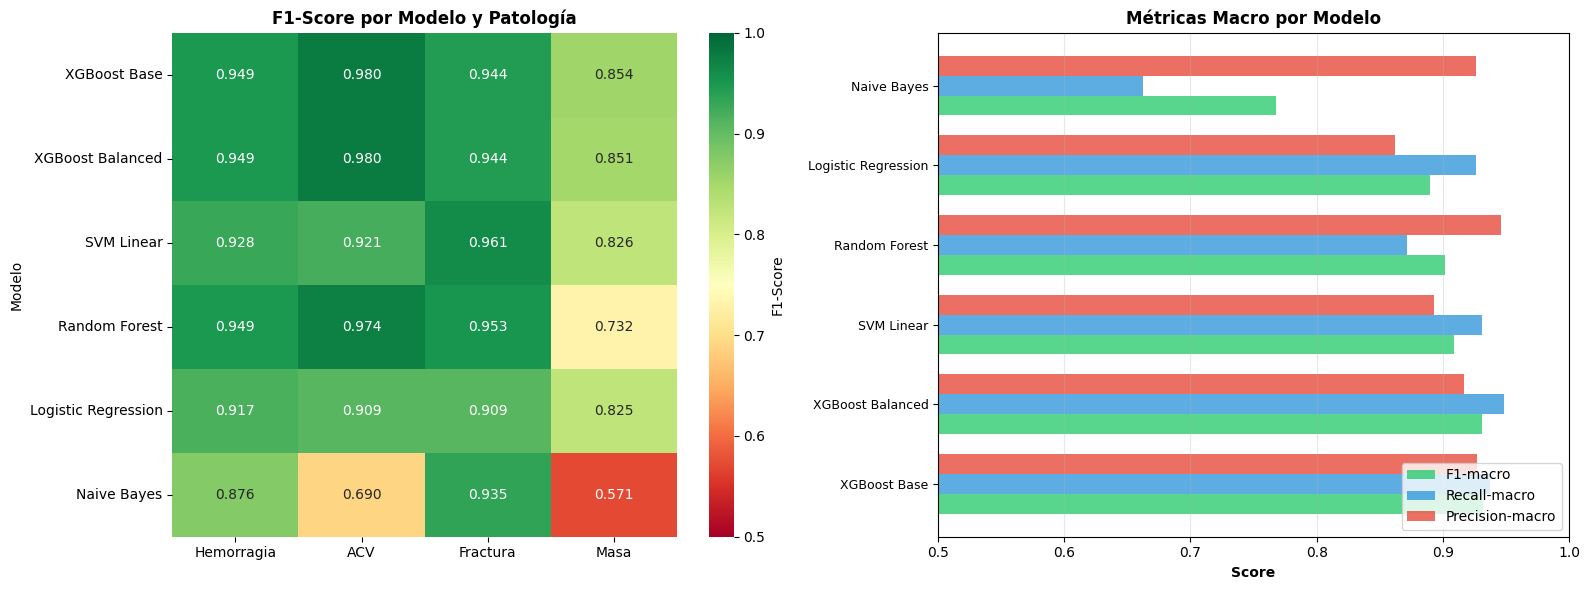

In [ ]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA GLOBAL
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Gráfico 1: Heatmap F1 por modelo y patología ───
df_heatmap = df_global[['F1_hemorragia', 'F1_acv', 'F1_fractura', 'F1_masa']].copy()
df_heatmap.columns = ['Hemorragia', 'ACV', 'Fractura', 'Masa']

sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=axes[0], cbar_kws={'label': 'F1-Score'})
axes[0].set_title('F1-Score por Modelo y Patología', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Modelo')

# ─── Gráfico 2: Barras comparativas de métricas macro ───
x = np.arange(len(df_global))
width = 0.25

axes[1].barh(x - width, df_global['F1_macro'], width, label='F1-macro', color='#2ecc71', alpha=0.8)
axes[1].barh(x, df_global['Recall_macro'], width, label='Recall-macro', color='#3498db', alpha=0.8)
axes[1].barh(x + width, df_global['Precision_macro'], width, label='Precision-macro', color='#e74c3c', alpha=0.8)

axes[1].set_xlabel('Score', fontweight='bold')
axes[1].set_title('Métricas Macro por Modelo', fontweight='bold', fontsize=12)
axes[1].set_yticks(x)
axes[1].set_yticklabels(df_global.index, fontsize=9)
axes[1].legend(loc='lower right')
axes[1].set_xlim([0.5, 1.0])
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Importancia de features (interpretabilidad)

Una ventaja clave de XGBoost es la capacidad de revelar qué features (n-gramas TF-IDF) son más discriminativas para cada patología. Esto permite validación clínica y transparencia del modelo.

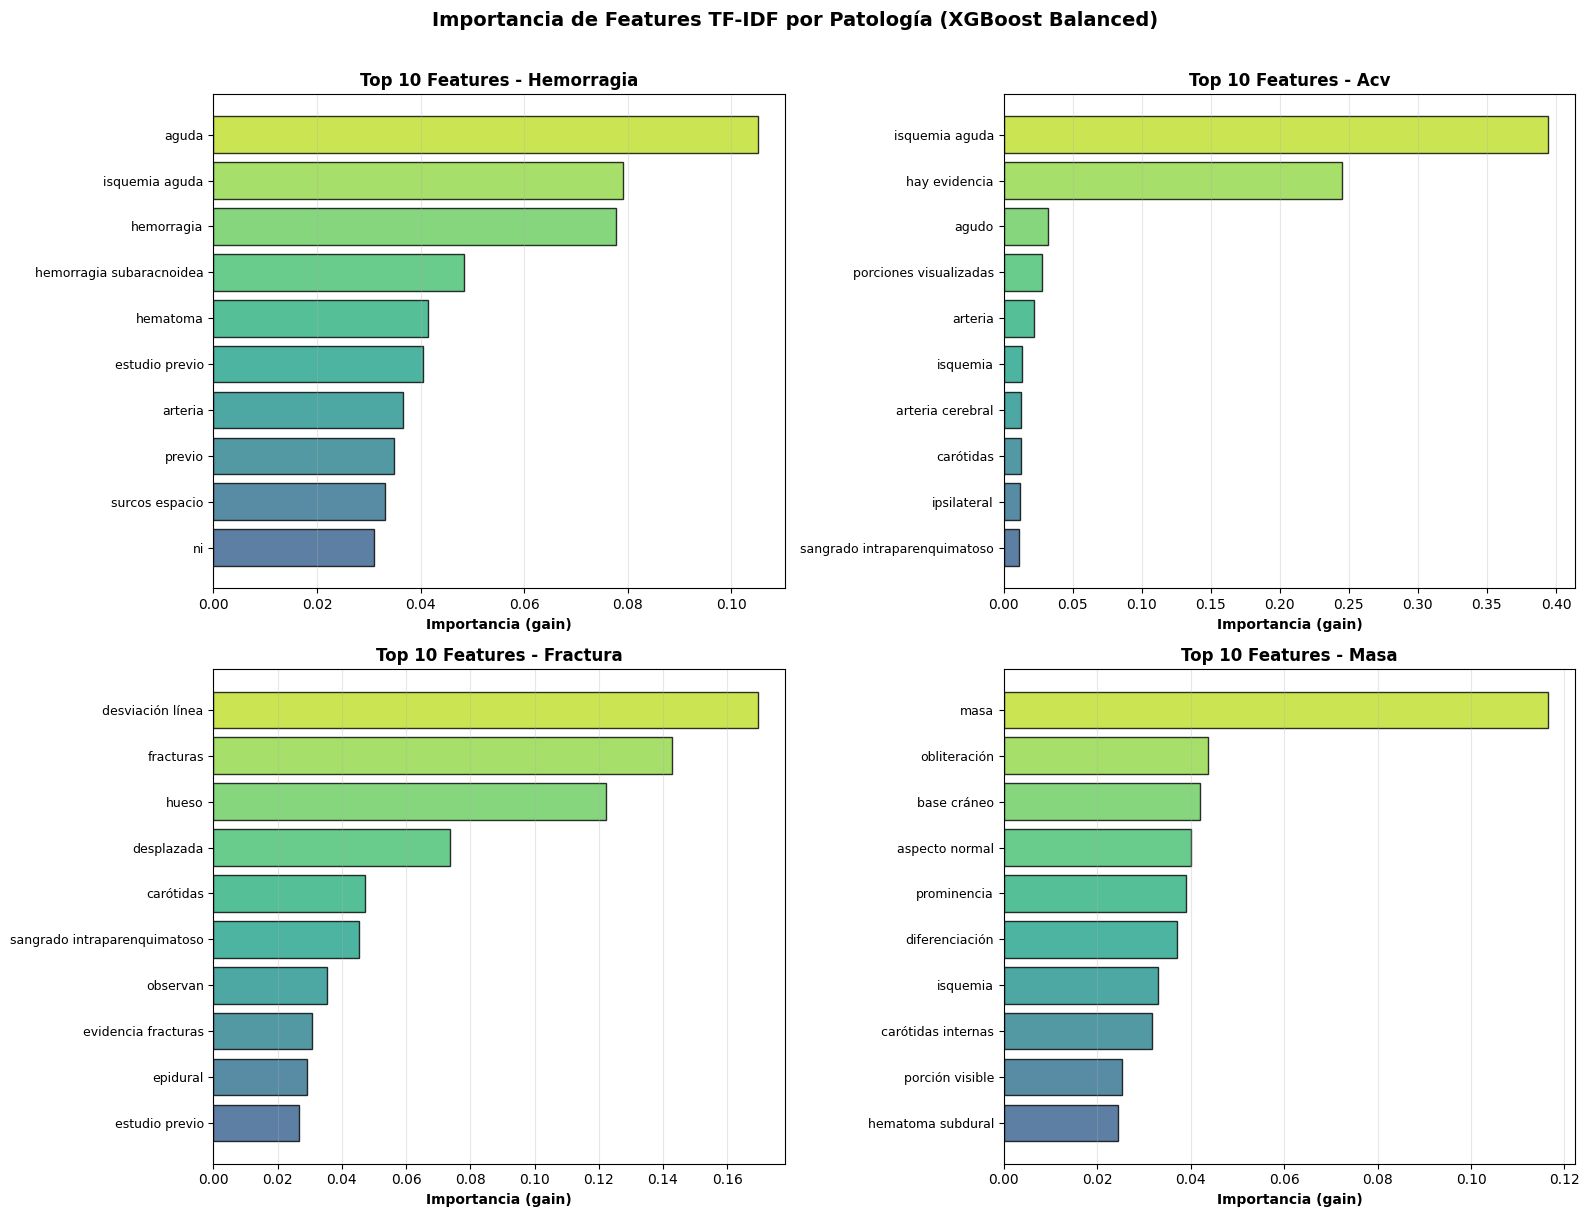

TOP 5 FEATURES MÁS IMPORTANTES POR PATOLOGÍA

  HEMORRAGIA:
    1. aguda                     (importancia: 0.1052)
    2. isquemia aguda            (importancia: 0.0791)
    3. hemorragia                (importancia: 0.0777)
    4. hemorragia subaracnoidea  (importancia: 0.0484)
    5. hematoma                  (importancia: 0.0414)

  ACV:
    1. isquemia aguda            (importancia: 0.3944)
    2. hay evidencia             (importancia: 0.2451)
    3. agudo                     (importancia: 0.0324)
    4. porciones visualizadas    (importancia: 0.0275)
    5. arteria                   (importancia: 0.0217)

  FRACTURA:
    1. desviación línea          (importancia: 0.1696)
    2. fracturas                 (importancia: 0.1430)
    3. hueso                     (importancia: 0.1222)
    4. desplazada                (importancia: 0.0736)
    5. carótidas                 (importancia: 0.0472)

  MASA:
    1. masa                      (importancia: 0.1165)
    2. obliteración           

In [ ]:
# =============================================================================
# IMPORTANCIA DE FEATURES POR PATOLOGÍA (TOP 10)
# =============================================================================

feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, patologia in enumerate(patologias):
    modelo = modelos_balanced[patologia]
    importances = modelo.feature_importances_
    
    # Top 10 features más importantes
    top_indices = np.argsort(importances)[-10:]
    top_features = feature_names[top_indices]
    top_values = importances[top_indices]
    
    ax = axes[idx]
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
    ax.barh(range(len(top_features)), top_values, color=colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=9)
    ax.set_xlabel('Importancia (gain)', fontweight='bold')
    ax.set_title(f'Top 10 Features - {patologia.capitalize()}', fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Importancia de Features TF-IDF por Patología (XGBoost Balanced)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Mostrar tabla de top 5 features por patología
print("=" * 70)
print("TOP 5 FEATURES MÁS IMPORTANTES POR PATOLOGÍA")
print("=" * 70)
for patologia in patologias:
    modelo = modelos_balanced[patologia]
    importances = modelo.feature_importances_
    top_indices = np.argsort(importances)[-5:][::-1]
    
    print(f"\n  {patologia.upper()}:")
    for rank, i in enumerate(top_indices, 1):
        print(f"    {rank}. {feature_names[i]:<25s} (importancia: {importances[i]:.4f})")

## 9. Conclusiones

### Resumen de resultados

| Modelo | F1-macro | Recall-macro | Precision-macro | F1-macro CV (K=5) |
|---|---|---|---|---|
| **XGBoost Base** | **0.9317** | 0.9371 | 0.9272 | 0.923 ± 0.014 ✔ |
| **XGBoost Balanced (SPW)** | 0.9310 | **0.9487** | 0.9168 | — |
| SVM Linear | 0.9090 | 0.9310 | 0.8930 | 0.898 ± 0.019 |
| Random Forest | 0.9020 | 0.8720 | **0.9460** | — |
| Logistic Regression | 0.8900 | 0.9260 | 0.8620 | — |
| Naive Bayes | 0.7680 | 0.6620 | 0.9260 | — |

*CV (K=5) de XGBoost calculado con Pipeline (TF-IDF ajustado dentro de cada fold, sin data leakage).*

### F1 por clase — XGBoost Base vs mejores baselines

| Patología | XGBoost Base | SVM Linear | Random Forest |
|---|---|---|---|
| hemorragia | **0.9488** | 0.9280 | **0.9490** |
| acv | **0.9801** | 0.9210 | 0.9740 |
| fractura | 0.9441 | **0.9610** | **0.9530** |
| masa | **0.8539** | 0.8260 | 0.7320 |

### Hallazgos clave

1. **XGBoost Base supera a todos los baselines en F1-macro** (0.9317 vs 0.9090 del SVM Linear), con mejoras particulares en `acv` (F1=0.9801, precisión perfecta de 1.000) y `masa` (F1=0.8539, +2.8pp sobre SVM, +12.2pp sobre RF).

2. **Efecto de `scale_pos_weight`**: El ajuste produjo impacto únicamente en `masa` (ΔRecall = +0.047), que es la clase con mayor desbalance (SPW=3.29). Las clases `hemorragia`, `acv` y `fractura` no registraron cambio, dado que sus ratios de desbalance son moderados o invertidos (hemorragia es clase mayoritaria, SPW=0.25). El modelo Balanced sacrifica 4.2pp de Precision en `masa` a cambio del incremento en Recall.

3. **Validación cruzada (Pipeline, sin leakage)**: F1-macro CV = **0.922 ± 0.014**, superior al SVM Linear (0.898 ± 0.019) en +2.4pp, con menor varianza inter-fold, confirmando que el rendimiento es robusto. La corrección del leakage generó una diferencia de solo -0.001 en F1-macro macro respecto a la versión anterior, indicando que el corpus clínico es suficientemente homogéneo léxicamente como para que el sesgo de IDF fuera mínimo.

4. **Interpretabilidad**: La importancia de features (sección 8) permite validación clínica directa de los n-gramas discriminativos por patología.

